# Expirements for the Image Sticthing App

In [126]:
import cv2 
import numpy as np
import pandas as pd
import sticth_app
import matplotlib.pyplot as plt

## Critical Stepps
1. Get All Features Into a Table

In [127]:
img_paths = sticth_app.get_image_files("/home/schmidtg/coding_projetcs/local-image-features-apps/image-stitching/datasets/example-data/myself")
orb = cv2.ORB_create()

img_id_bounds = np.array([0], dtype=np.uint32)  # indicated at which ID an image starts/end
N = 0
des = np.empty((0,32), dtype=np.uint8) # data type is crucial!
img_ids = np.empty((0))
kps = ()

for img_id, img_path in enumerate(img_paths): 
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    kp_new, des_new = orb.detectAndCompute(img, None)  # type: ignore
    des = np.vstack((des, des_new))
    kps +=  kp_new
    N_new = len(des_new)
    N += N_new
    img_id_bounds = np.append(img_id_bounds, N)
    img_ids_new = np.full((N_new), img_id+1)
    img_ids = np.concatenate((img_ids, img_ids_new), axis=0)

In [128]:
len(kp_new)

500

In [129]:
len(kps)

5500

In [130]:
# descriptor IDs from at 0 until 499, belong to Image ID 1
# descriptor IDs from at 500 until 999, belong to Image ID 2
# ...
# descriptor IDs from at 1500 until 1999, belong to Image ID 4
img_id_bounds

array([   0,  500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000,
       5500])

In [131]:
img_ids

array([ 1.,  1.,  1., ..., 11., 11., 11.], shape=(5500,))

In [132]:
des

array([[105, 149,  87, ..., 114, 227,  51],
       [226, 167,  69, ..., 130, 198,  60],
       [118, 166, 193, ..., 131, 134, 114],
       ...,
       [186, 186, 100, ...,   4, 126, 223],
       [ 42, 237, 148, ...,  92, 189, 142],
       [  1, 141,  31, ..., 192, 129, 169]], shape=(5500, 32), dtype=uint8)

In [133]:
matching_df = pd.DataFrame(
    {"Descriptor" : list(des),
     "ImgId" : img_ids})
convert_dict ={"ImgId": np.uint8}  # dont expect more than 2^8 / 255 images
matching_df = matching_df.astype(convert_dict)
print(matching_df.dtypes)
print("Descriptor dtype:", type(matching_df["Descriptor"].iloc[0]), matching_df["Descriptor"].iloc[0].dtype)
matching_df.head()

Descriptor    object
ImgId          uint8
dtype: object
Descriptor dtype: <class 'numpy.ndarray'> uint8


,Descriptor,ImgId
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1


In [134]:
x = np.stack(list(matching_df["Descriptor"]))
x

array([[105, 149,  87, ..., 114, 227,  51],
       [226, 167,  69, ..., 130, 198,  60],
       [118, 166, 193, ..., 131, 134, 114],
       ...,
       [186, 186, 100, ...,   4, 126, 223],
       [ 42, 237, 148, ...,  92, 189, 142],
       [  1, 141,  31, ..., 192, 129, 169]], shape=(5500, 32), dtype=uint8)

In [135]:
# Define FLANN parameters and match descriptors
# from https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html
FLANN_INDEX_LSH = 6
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6, # 12
                   key_size = 12,     # 20
                   multi_probe_level = 1) #2
search_params = dict(checks=50)   # or pass empty dictionary
flann = cv2.FlannBasedMatcher(index_params, search_params)
matches = flann.knnMatch(x,x, k=5)

# 2nd Method, Not Working
# FLANN_INDEX_KDTREE = 0
# index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)
# search_params = dict(checks=50)
# flann = cv2.FlannBasedMatcher(index_params, search_params)
# matches = flann.knnMatch(des, des, k=2)

In [136]:
# queryIdx == OG DescriptorID  trainIdx == matched DescriptorID 
matched_col = [np.array([m.trainIdx for m in M[1:]]) for M in matches]

In [137]:
matching_df['Matched_Ids'] = matched_col

In [138]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1,"[5073, 3547, 3138, 5189]"
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1,"[690, 684, 2562, 4294]"
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1,"[145, 4354, 3213, 3309]"
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1,"[85, 3230, 1233, 3663]"
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1,"[5075, 192, 3658, 4038]"


In [139]:
# convert matched descriptor ids to img ids 
def descriptor_id_to_img_id(id,bounds) -> int:
    """
    Get the associated Image ID for the given Descriptor ID, using the given bounds. 
    Returns:
        int: in range from 1 to length of bounds
    """
    return np.searchsorted(bounds, id, side='right')

def matched_ids_to_img_ids(row, bounds):
    matched_ids = row['Matched_Ids']
    img_ids = [descriptor_id_to_img_id(id, bounds) for id in matched_ids]
    return np.array(img_ids)

matching_df['Matched_ImgIds'] = matching_df.apply(matched_ids_to_img_ids, 
                                                  axis=1, 
                                                  args=(img_id_bounds,))

In [140]:
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1,"[5073, 3547, 3138, 5189]","[11, 8, 7, 11]"
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1,"[690, 684, 2562, 4294]","[2, 2, 6, 9]"
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1,"[145, 4354, 3213, 3309]","[1, 9, 7, 7]"
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1,"[85, 3230, 1233, 3663]","[1, 7, 3, 8]"
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1,"[5075, 192, 3658, 4038]","[11, 1, 8, 9]"


In [141]:
# remove Matched Ids of descriptors that belong to the same image
def remove_invalid_matches(row) -> pd.Series:
    """
    Remnoves Ids from Matched_Ids that are the are from the same Image (ImgId)

    Args:
        row: a row from a pandas dataframe

    Returns:
        series: a series for containing the updated Matched_Ids and Matched_ImgIds, with invalid values removed.
    """
    matched_ids, img_ids, imgId = row['Matched_Ids'], row['Matched_ImgIds'], row['ImgId'] 
    indeces_to_remove = np.where(img_ids == imgId)
    # create mask to remove values
    mask = np.ones(len(matched_ids), dtype=bool)
    mask[indeces_to_remove] = False
    matched_ids = matched_ids[mask,...]
    img_ids = img_ids[mask,...]
    return pd.Series([matched_ids, img_ids])

In [142]:
matching_df[["Matched_Ids", "Matched_ImgIds"]] = matching_df.apply(remove_invalid_matches, axis=1)
matching_df.head()

,Descriptor,ImgId,Matched_Ids,Matched_ImgIds
0,"[105, 149, 87, 110, 242, 206, 39, 55, 112, 2, ...",1,"[5073, 3547, 3138, 5189]","[11, 8, 7, 11]"
1,"[226, 167, 69, 75, 152, 138, 75, 175, 35, 53, ...",1,"[690, 684, 2562, 4294]","[2, 2, 6, 9]"
2,"[118, 166, 193, 33, 153, 47, 75, 155, 55, 61, ...",1,"[4354, 3213, 3309]","[9, 7, 7]"
3,"[15, 187, 20, 107, 176, 159, 120, 209, 47, 57,...",1,"[3230, 1233, 3663]","[7, 3, 8]"
4,"[24, 95, 39, 255, 52, 230, 111, 55, 181, 202, ...",1,"[5075, 3658, 4038]","[11, 8, 9]"


In [143]:
# Get the counts of imag matches
img_id_stats_df = matching_df.explode('Matched_ImgIds')
result = (
    img_id_stats_df
    .groupby(['ImgId', 'Matched_ImgIds'])
    .size()
    .reset_index(name='Count')
    .rename(columns={'Matched_ImgIds': 'MatchedWith'})
)

print(result)

     ImgId  MatchedWith  Count
0        1            2    283
1        1            3     81
2        1            4    101
3        1            5     86
4        1            6    103
..     ...          ...    ...
105     11            6     76
106     11            7    100
107     11            8    104
108     11            9     71
109     11           10    247

[110 rows x 3 columns]


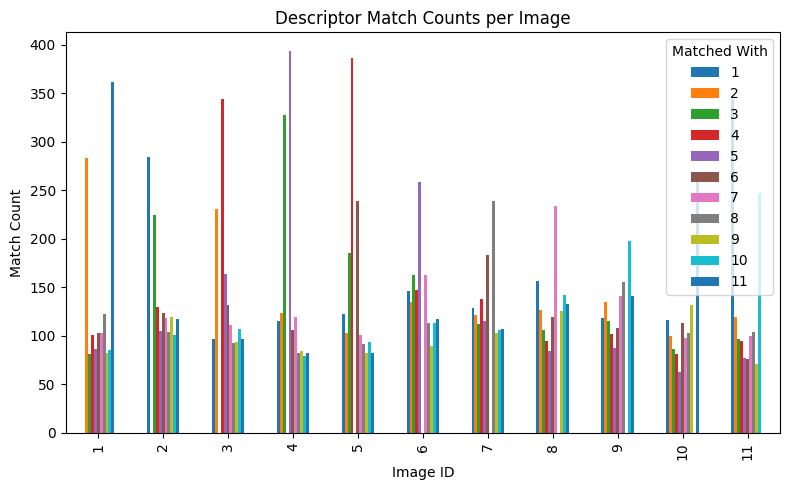

In [144]:
# Pivot the data so each "MatchedWith" becomes a column
pivot_df = result.pivot(index='ImgId', columns='MatchedWith', values='Count').fillna(0)

# Plot grouped bars
pivot_df.plot(kind='bar', figsize=(8,5))

plt.title("Descriptor Match Counts per Image")
plt.xlabel("Image ID")
plt.ylabel("Match Count")
plt.legend(title="Matched With")
plt.tight_layout()
plt.show()

In [147]:
top_matches = (
    result
    .sort_values(['ImgId', 'Count'], ascending=[True, False])
    .groupby('ImgId')['MatchedWith']
    .apply(list)
    .to_dict()
)

top_matches

{1: [11, 2, 8, 6, 7, 4, 5, 10, 9, 3],
 2: [1, 3, 4, 6, 9, 7, 11, 5, 8, 10],
 3: [4, 2, 5, 6, 7, 10, 1, 11, 9, 8],
 4: [5, 3, 2, 7, 1, 6, 9, 8, 11, 10],
 5: [4, 6, 3, 1, 2, 7, 10, 8, 9, 11],
 6: [5, 3, 7, 4, 1, 2, 11, 8, 10, 9],
 7: [8, 6, 4, 1, 2, 5, 3, 11, 10, 9],
 8: [7, 1, 10, 11, 2, 9, 6, 3, 4, 5],
 9: [10, 8, 7, 11, 2, 1, 3, 6, 4, 5],
 10: [11, 9, 1, 6, 8, 2, 7, 3, 4, 5],
 11: [1, 10, 2, 8, 7, 3, 4, 5, 6, 9]}